# Семинар: Компьютерное зрение. 
## GAN & VAE. Часть 2.
## Обучение StyleGAN на Сeleba DataSet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

### 1. Подготовка датасета

In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 64

transform_celeba = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

celeba_dataset = datasets.CelebA(
    root='./data', split='train', transform=transform_celeba, download=True
)
train_loader = DataLoader(
    celeba_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True
)

print(f"Dataset: {len(celeba_dataset)} images")


def show_celeba_grid(dataloader: DataLoader, n_samples: int = 16) -> plt.Figure:
    """Показать примеры из CelebA"""
    images, _ = next(iter(dataloader))
    
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    for i in range(min(n_samples, len(images))):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)
        
        axes[i].imshow(img)
        axes[i].axis('off')
    
    plt.suptitle('CelebA Dataset Samples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

print("\n🎨 Примеры из CelebA:")
fig = show_celeba_grid(train_loader_celeba)
plt.savefig('celeba_samples.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Имплементируем упрощенную версию StyleGAN1

In [ ]:
class PixelNorm(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return x * torch.rsqrt(torch.mean(x ** 2, dim=1, keepdim=True) + 1e-8)


class EqualizedLinear(nn.Module):
    """
    Инициализируем все веса одинаково (N(0, 1))
    Применяем масштабирование во время forward pass
    """
    def __init__(self, in_dim, out_dim, gain=2 ** 0.5, use_wscale=True, lrmul=1.0, bias=True):
        super().__init__()
        
        he_std = gain * in_dim ** (-0.5)
        if use_wscale:
            init_std = 1.0 / lrmul
            self.w_mul = he_std * lrmul
        else:
            init_std = he_std / lrmul
            self.w_mul = lrmul
        
        self.weight = nn.Parameter(torch.randn(out_dim, in_dim) * init_std)
        
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_dim))
        else:
            self.bias = None
    
    def forward(self, x):
        return F.linear(x, self.weight * self.w_mul, self.bias)


class EqualizedConv2d(nn.Module):
    """
    Инициализируем все веса одинаково (N(0, 1))
    Применяем масштабирование во время forward pass
    """
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0, gain=2 ** 0.5, use_wscale=True, lrmul=1.0):
        super().__init__()
        
        he_std = gain * (in_ch * kernel_size ** 2) ** (-0.5)
        if use_wscale:
            init_std = 1.0 / lrmul
            self.w_mul = he_std * lrmul
        else:
            init_std = he_std / lrmul
            self.w_mul = lrmul
        
        self.weight = nn.Parameter(torch.randn(out_ch, in_ch, kernel_size, kernel_size) * init_std)
        self.bias = nn.Parameter(torch.zeros(out_ch))
        self.stride = stride
        self.padding = padding
    
    def forward(self, x):
        return F.conv2d(x, self.weight * self.w_mul, self.bias, self.stride, self.padding)


class AdaptiveInstanceNorm(nn.Module):
    def __init__(self, in_channel, style_dim):
        super().__init__()
        
        self.style = EqualizedLinear(style_dim, in_channel * 2)
        
        self.style.bias.data[:in_channel] = 1
        self.style.bias.data[in_channel:] = 0
    
    def forward(self, x, w):
        x_mean = x.mean(dim=[2, 3], keepdim=True)
        x_std = x.std(dim=[2, 3], keepdim=True) + 1e-8
        x_normalized = (x - x_mean) / x_std
        
        style = self.style(w).unsqueeze(2).unsqueeze(3)
        gamma, beta = style.chunk(2, dim=1)
        
        out = gamma * x_normalized + beta
        
        return out


class NoiseLayer(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(channels))
    
    def forward(self, x, noise=None):
        if noise is None:
            batch, _, height, width = x.shape
            noise = x.new_empty(batch, 1, height, width).normal_()
        
        return x + self.weight.view(1, -1, 1, 1) * noise


class StyleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, style_dim, upsample=False):
        super().__init__()
        
        self.upsample = upsample
        
        if upsample:
            self.upsample_layer = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        
        self.conv = EqualizedConv2d(in_ch, out_ch, 3, padding=1)
        self.noise = NoiseLayer(out_ch)
        self.adain = AdaptiveInstanceNorm(out_ch, style_dim)
        self.activation = nn.LeakyReLU(0.2)
    
    def forward(self, x, w, noise=None):
        if self.upsample:
            x = self.upsample_layer(x)
        
        x = self.conv(x)
        x = self.noise(x, noise)
        x = self.activation(x)
        x = self.adain(x, w)
        
        return x


class MappingNetwork(nn.Module):
    def __init__(self, z_dim=512, w_dim=512, n_layers=8, lrmul=0.01):
        super().__init__()
        
        layers = [PixelNorm()]
        
        for i in range(n_layers):
            layers.append(EqualizedLinear(
                z_dim if i == 0 else w_dim,
                w_dim,
                lrmul=lrmul
            ))
            layers.append(nn.LeakyReLU(0.2))
        
        self.mapping = nn.Sequential(*layers)
    
    def forward(self, z):
        return self.mapping(z)


class StyleGANv1Generator(nn.Module):
    def __init__(self, z_dim=512, w_dim=512, img_size=64):
        super().__init__()
        self.z_dim = z_dim
        self.w_dim = w_dim

        # стилевая составляющая
        self.mapping = MappingNetwork(z_dim, w_dim)

        # обучаемая константа
        self.const = nn.Parameter(torch.randn(1, 512, 4, 4))

        # упрjщенная структура блоков (по обдному на каждое вмсето двух)
        self.blocks = nn.ModuleList([
            StyleBlock(512, 512, w_dim, upsample=False),
            StyleBlock(512, 512, w_dim, upsample=True),
            StyleBlock(512, 256, w_dim, upsample=True),
            StyleBlock(256, 128, w_dim, upsample=True),
            StyleBlock(128, 64, w_dim, upsample=True),
        ])

        # упрощено: только один to_rgb
        self.to_rgb = EqualizedConv2d(64, 3, 1)
    
    def forward(self, z, return_latents=False):
        # забьем на Progressive Growing
        
        w = self.mapping(z)
        # пропустим Truncation Trick

        x = self.const.repeat(z.size(0), 1, 1, 1)

        # без style mixing
        for block in self.blocks:
            x = block(x, w)
        
        image = self.to_rgb(x)
        image = torch.tanh(image)
        
        if return_latents:
            return image, w
        return image


class MinibatchStdDev(nn.Module):
    """Упрошенная версия, без деления батча"""
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        batch, channel, height, width = x.shape
        
        # Вычисляем stddev по батчу для каждого пикселя
        # Усредняем по каналам и пространству -> один скаляр
        stddev = x.std(dim=0, unbiased=False).mean()  # Один скаляр
        
        # Создаём канал со stddev для каждого элемента батча
        stddev_channel = stddev.repeat(batch, 1, height, width)  # [B, 1, H, W]
        
        # Конкатенируем
        return torch.cat([x, stddev_channel], dim=1)  # [B, C+1, H, W]


class StyleGANv1Discriminator(nn.Module):

    def __init__(self):
        super().__init__()
        
        self.from_rgb = EqualizedConv2d(3, 64, 1)
        
        self.blocks = nn.Sequential(
            # 64x64 -> 32x32
            EqualizedConv2d(64, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(64, 128, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
            
            # 32x32 -> 16x16
            EqualizedConv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(128, 256, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
            
            # 16x16 -> 8x8
            EqualizedConv2d(256, 256, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(256, 512, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
            
            # 8x8 -> 4x4
            EqualizedConv2d(512, 512, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(512, 512, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
        )
        
        # Используем упрощённую версию
        self.minibatch_stddev = MinibatchStdDev()
        
        self.final_conv = EqualizedConv2d(513, 512, 3, padding=1)
        self.final_linear = nn.Sequential(
            nn.Flatten(),
            EqualizedLinear(512 * 4 * 4, 512),
            nn.LeakyReLU(0.2),
            EqualizedLinear(512, 1)
        )
    
    def forward(self, x):
        x = F.leaky_relu(self.from_rgb(x), 0.2)
        x = self.blocks(x)

        x = self.minibatch_stddev(x)
        
        x = F.leaky_relu(self.final_conv(x), 0.2)
        x = self.final_linear(x)
        
        return x



### 3. Пишем скрипт обучения

In [ ]:
def train_stylegan_v1(generator, discriminator, train_loader, epochs=100):
    """StyleGAN v1 training"""
    
    g_optim = torch.optim.Adam(generator.parameters(), lr=0.001, betas=(0.0, 0.99), eps=1e-8)
    d_optim = torch.optim.Adam(discriminator.parameters(), lr=0.001, betas=(0.0, 0.99), eps=1e-8)
    
    fixed_z = torch.randn(16, 512, device=device)
    
    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        
        g_loss_sum = 0
        d_loss_sum = 0
        
        for i, (real_imgs, _) in enumerate(pbar):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            
            # ==================== Update Discriminator ====================
            d_optim.zero_grad()
            
            # Real
            real_imgs.requires_grad = True
            real_pred = discriminator(real_imgs)
            d_loss_real = F.softplus(-real_pred).mean()
            
            # Fake
            z = torch.randn(batch_size, 512, device=device)
            fake_imgs = generator(z).detach()
            fake_pred = discriminator(fake_imgs)
            d_loss_fake = F.softplus(fake_pred).mean()
            
            d_loss = d_loss_real + d_loss_fake
            
            # R1 regularization
            if i % 16 == 0:
                grad_real = torch.autograd.grad(
                    outputs=real_pred.sum(), inputs=real_imgs, create_graph=True
                )[0]
                r1_penalty = grad_real.pow(2).view(batch_size, -1).sum(1).mean()
                d_loss = d_loss + 10.0 * r1_penalty
            
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            d_optim.step()
            
            real_imgs.requires_grad = False
            
            # ==================== Update Generator ====================
            g_optim.zero_grad()
            
            z = torch.randn(batch_size, 512, device=device)
            fake_imgs = generator(z)
            fake_pred = discriminator(fake_imgs)
            
            g_loss = F.softplus(-fake_pred).mean()
            
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            g_optim.step()
            
            # Stats
            g_loss_sum += g_loss.item()
            d_loss_sum += d_loss.item()
            
            pbar.set_postfix({
                'g': f'{g_loss.item():.3f}',
                'd': f'{d_loss.item():.3f}',
                'real': f'{torch.sigmoid(real_pred).mean().item():.3f}',
                'fake': f'{torch.sigmoid(fake_pred).mean().item():.3f}'
            })
        
        # Epoch summary
        print(f'\n📊 Epoch {epoch+1}: G={g_loss_sum/len(train_loader):.4f}, D={d_loss_sum/len(train_loader):.4f}')
        
        # Generate samples
        if (epoch + 1) % 5 == 0 or epoch == 0:
            generator.eval()
            with torch.no_grad():
                samples = generator(fixed_z)
                
                fig, axes = plt.subplots(4, 4, figsize=(10, 10))
                for idx, ax in enumerate(axes.flatten()):
                    img = samples[idx].cpu().permute(1, 2, 0).numpy()
                    img = (img * 0.5 + 0.5).clip(0, 1)
                    ax.imshow(img)
                    ax.axis('off')
                
                plt.suptitle(f'StyleGAN v1 - Epoch {epoch+1}', fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.savefig(f'stylegan_v1_epoch_{epoch+1}.png', dpi=100)
                plt.close()
                
                print(f'💾 Saved: stylegan_v1_epoch_{epoch+1}.png')
            
            generator.train()
            
            torch.save({
                'epoch': epoch,
                'generator': generator.state_dict(),
                'discriminator': discriminator.state_dict(),
            }, f'stylegan_v1_checkpoint_{epoch+1}.pth')


In [4]:
## Dataset
IMG_SIZE = 64
BATCH_SIZE = 64

transform_celeba = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

celeba_dataset = datasets.CelebA(
    root='./data', split='train', transform=transform_celeba, download=True
)
train_loader = DataLoader(
    celeba_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True
)

print(f"Dataset: {len(celeba_dataset)} images")


## Components 

class PixelNorm(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return x * torch.rsqrt(torch.mean(x ** 2, dim=1, keepdim=True) + 1e-8)


class EqualizedLinear(nn.Module):
    def __init__(self, in_dim, out_dim, gain=2 ** 0.5, use_wscale=True, lrmul=1.0, bias=True):
        super().__init__()
        
        he_std = gain * in_dim ** (-0.5)
        if use_wscale:
            init_std = 1.0 / lrmul
            self.w_mul = he_std * lrmul
        else:
            init_std = he_std / lrmul
            self.w_mul = lrmul
        
        self.weight = nn.Parameter(torch.randn(out_dim, in_dim) * init_std)
        
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_dim))
        else:
            self.bias = None
    
    def forward(self, x):
        return F.linear(x, self.weight * self.w_mul, self.bias)


class EqualizedConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0, gain=2 ** 0.5, use_wscale=True, lrmul=1.0):
        super().__init__()
        
        he_std = gain * (in_ch * kernel_size ** 2) ** (-0.5)
        if use_wscale:
            init_std = 1.0 / lrmul
            self.w_mul = he_std * lrmul
        else:
            init_std = he_std / lrmul
            self.w_mul = lrmul
        
        self.weight = nn.Parameter(torch.randn(out_ch, in_ch, kernel_size, kernel_size) * init_std)
        self.bias = nn.Parameter(torch.zeros(out_ch))
        self.stride = stride
        self.padding = padding
    
    def forward(self, x):
        return F.conv2d(x, self.weight * self.w_mul, self.bias, self.stride, self.padding)


class AdaptiveInstanceNorm(nn.Module):
    def __init__(self, in_channel, style_dim):
        super().__init__()
        
        self.style = EqualizedLinear(style_dim, in_channel * 2)
        
        self.style.bias.data[:in_channel] = 1
        self.style.bias.data[in_channel:] = 0
    
    def forward(self, x, w):
        x_mean = x.mean(dim=[2, 3], keepdim=True)
        x_std = x.std(dim=[2, 3], keepdim=True) + 1e-8
        x_normalized = (x - x_mean) / x_std
        
        style = self.style(w).unsqueeze(2).unsqueeze(3)
        gamma, beta = style.chunk(2, dim=1)
        
        out = gamma * x_normalized + beta
        
        return out


class NoiseLayer(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(channels))
    
    def forward(self, x, noise=None):
        if noise is None:
            batch, _, height, width = x.shape
            noise = x.new_empty(batch, 1, height, width).normal_()
        
        return x + self.weight.view(1, -1, 1, 1) * noise


class StyleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, style_dim, upsample=False):
        super().__init__()
        
        self.upsample = upsample
        
        if upsample:
            self.upsample_layer = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        
        self.conv = EqualizedConv2d(in_ch, out_ch, 3, padding=1)
        self.noise = NoiseLayer(out_ch)
        self.adain = AdaptiveInstanceNorm(out_ch, style_dim)
        self.activation = nn.LeakyReLU(0.2)
    
    def forward(self, x, w, noise=None):
        if self.upsample:
            x = self.upsample_layer(x)
        
        x = self.conv(x)
        x = self.noise(x, noise)
        x = self.activation(x)
        x = self.adain(x, w)
        
        return x


class MappingNetwork(nn.Module):
    def __init__(self, z_dim=512, w_dim=512, n_layers=8, lrmul=0.01):
        super().__init__()
        
        layers = [PixelNorm()]
        
        for i in range(n_layers):
            layers.append(EqualizedLinear(
                z_dim if i == 0 else w_dim,
                w_dim,
                lrmul=lrmul
            ))
            layers.append(nn.LeakyReLU(0.2))
        
        self.mapping = nn.Sequential(*layers)
    
    def forward(self, z):
        return self.mapping(z)


class StyleGANv1Generator(nn.Module):
    def __init__(self, z_dim=512, w_dim=512, img_size=64):
        super().__init__()
        self.z_dim = z_dim
        self.w_dim = w_dim
        
        self.mapping = MappingNetwork(z_dim, w_dim)
        
        self.const = nn.Parameter(torch.randn(1, 512, 4, 4))
        
        self.blocks = nn.ModuleList([
            StyleBlock(512, 512, w_dim, upsample=False),
            StyleBlock(512, 512, w_dim, upsample=True),
            StyleBlock(512, 256, w_dim, upsample=True),
            StyleBlock(256, 128, w_dim, upsample=True),
            StyleBlock(128, 64, w_dim, upsample=True),
        ])
        
        self.to_rgb = EqualizedConv2d(64, 3, 1)
    
    def forward(self, z, return_latents=False):
        w = self.mapping(z)
        
        x = self.const.repeat(z.size(0), 1, 1, 1)
        
        for block in self.blocks:
            x = block(x, w)
        
        image = self.to_rgb(x)
        image = torch.tanh(image)
        
        if return_latents:
            return image, w
        return image


class MinibatchStdDev(nn.Module):
    """✅ УПРОЩЁННАЯ и НАДЁЖНАЯ версия minibatch stddev"""
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        batch, channel, height, width = x.shape
        
        # Вычисляем stddev по батчу для каждого пикселя
        # Усредняем по каналам и пространству -> один скаляр
        stddev = x.std(dim=0, unbiased=False).mean()  # Один скаляр
        
        # Создаём канал со stddev для каждого элемента батча
        stddev_channel = stddev.repeat(batch, 1, height, width)  # [B, 1, H, W]
        
        # Конкатенируем
        return torch.cat([x, stddev_channel], dim=1)  # [B, C+1, H, W]


class StyleGANv1Discriminator(nn.Module):
    """✅ ИСПРАВЛЕННЫЙ Discriminator"""
    def __init__(self):
        super().__init__()
        
        self.from_rgb = EqualizedConv2d(3, 64, 1)
        
        self.blocks = nn.Sequential(
            # 64x64 -> 32x32
            EqualizedConv2d(64, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(64, 128, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
            
            # 32x32 -> 16x16
            EqualizedConv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(128, 256, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
            
            # 16x16 -> 8x8
            EqualizedConv2d(256, 256, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(256, 512, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
            
            # 8x8 -> 4x4
            EqualizedConv2d(512, 512, 3, padding=1),
            nn.LeakyReLU(0.2),
            EqualizedConv2d(512, 512, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AvgPool2d(2),
        )
        
        # ✅ Используем упрощённую версию
        self.minibatch_stddev = MinibatchStdDev()
        
        self.final_conv = EqualizedConv2d(513, 512, 3, padding=1)
        self.final_linear = nn.Sequential(
            nn.Flatten(),
            EqualizedLinear(512 * 4 * 4, 512),
            nn.LeakyReLU(0.2),
            EqualizedLinear(512, 1)
        )
    
    def forward(self, x):
        x = F.leaky_relu(self.from_rgb(x), 0.2)
        x = self.blocks(x)
        
        # ✅ Применяем minibatch stddev
        x = self.minibatch_stddev(x)
        
        x = F.leaky_relu(self.final_conv(x), 0.2)
        x = self.final_linear(x)
        
        return x


## Training

def train_stylegan_v1(generator, discriminator, train_loader, epochs=100):
    """StyleGAN v1 training"""
    
    g_optim = torch.optim.Adam(generator.parameters(), lr=0.001, betas=(0.0, 0.99), eps=1e-8)
    d_optim = torch.optim.Adam(discriminator.parameters(), lr=0.001, betas=(0.0, 0.99), eps=1e-8)
    
    fixed_z = torch.randn(16, 512, device=device)
    
    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        
        g_loss_sum = 0
        d_loss_sum = 0
        
        for i, (real_imgs, _) in enumerate(pbar):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            
            # ==================== Update Discriminator ====================
            d_optim.zero_grad()
            
            # Real
            real_imgs.requires_grad = True
            real_pred = discriminator(real_imgs)
            d_loss_real = F.softplus(-real_pred).mean()
            
            # Fake
            z = torch.randn(batch_size, 512, device=device)
            fake_imgs = generator(z).detach()
            fake_pred = discriminator(fake_imgs)
            d_loss_fake = F.softplus(fake_pred).mean()
            
            d_loss = d_loss_real + d_loss_fake
            
            # R1 regularization
            if i % 16 == 0:
                grad_real = torch.autograd.grad(
                    outputs=real_pred.sum(), inputs=real_imgs, create_graph=True
                )[0]
                r1_penalty = grad_real.pow(2).view(batch_size, -1).sum(1).mean()
                d_loss = d_loss + 10.0 * r1_penalty
            
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            d_optim.step()
            
            real_imgs.requires_grad = False
            
            # ==================== Update Generator ====================
            g_optim.zero_grad()
            
            z = torch.randn(batch_size, 512, device=device)
            fake_imgs = generator(z)
            fake_pred = discriminator(fake_imgs)
            
            g_loss = F.softplus(-fake_pred).mean()
            
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            g_optim.step()
            
            # Stats
            g_loss_sum += g_loss.item()
            d_loss_sum += d_loss.item()
            
            pbar.set_postfix({
                'g': f'{g_loss.item():.3f}',
                'd': f'{d_loss.item():.3f}',
                'real': f'{torch.sigmoid(real_pred).mean().item():.3f}',
                'fake': f'{torch.sigmoid(fake_pred).mean().item():.3f}'
            })
        
        # Epoch summary
        print(f'\n📊 Epoch {epoch+1}: G={g_loss_sum/len(train_loader):.4f}, D={d_loss_sum/len(train_loader):.4f}')
        
        # Generate samples
        if (epoch + 1) % 5 == 0 or epoch == 0:
            generator.eval()
            with torch.no_grad():
                samples = generator(fixed_z)
                
                fig, axes = plt.subplots(4, 4, figsize=(10, 10))
                for idx, ax in enumerate(axes.flatten()):
                    img = samples[idx].cpu().permute(1, 2, 0).numpy()
                    img = (img * 0.5 + 0.5).clip(0, 1)
                    ax.imshow(img)
                    ax.axis('off')
                
                plt.suptitle(f'StyleGAN v1 - Epoch {epoch+1}', fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.savefig(f'stylegan_v1_epoch_{epoch+1}.png', dpi=100)
                plt.close()
                
                print(f'💾 Saved: stylegan_v1_epoch_{epoch+1}.png')
            
            generator.train()
            
            torch.save({
                'epoch': epoch,
                'generator': generator.state_dict(),
                'discriminator': discriminator.state_dict(),
            }, f'stylegan_v1_checkpoint_{epoch+1}.pth')


## Initialize and train

print("\n" + "="*70)
print("STYLEGAN V1")
print("="*70)

gen = StyleGANv1Generator(z_dim=512, w_dim=512, img_size=64).to(device)
disc = StyleGANv1Discriminator().to(device)

print(f"\nGenerator: {sum(p.numel() for p in gen.parameters())/1e6:.2f}M params")
print(f"Discriminator: {sum(p.numel() for p in disc.parameters())/1e6:.2f}M params")

# Test
print("\n Testing:")
with torch.no_grad():
    z_test = torch.randn(2, 512, device=device)
    img = gen(z_test)
    out = disc(img)
    print(f"  {z_test.shape} -> {img.shape} -> {out.shape}")
    print(f"  ✅ All shapes correct!")

print("\n Training StyleGAN v1...\n")
train_stylegan_v1(gen, disc, train_loader, epochs=100)

Device: cuda:1
Files already downloaded and verified
Dataset: 162770 images

STYLEGAN V1 - FIXED

Generator: 9.89M params
Discriminator: 13.60M params

🔍 Testing:
  torch.Size([2, 512]) -> torch.Size([2, 3, 64, 64]) -> torch.Size([2, 1])
  ✅ All shapes correct!

🚀 Training StyleGAN v1...



Epoch 1/100: 100%|████████████████████████████████████| 2543/2543 [05:19<00:00,  7.97it/s, g=0.588, d=0.834, real=0.552, fake=0.566]



📊 Epoch 1: G=2.7466, D=0.7529
💾 Saved: stylegan_v1_epoch_1.png


Epoch 2/100: 100%|████████████████████████████████████| 2543/2543 [05:19<00:00,  7.97it/s, g=0.950, d=0.853, real=0.597, fake=0.394]



📊 Epoch 2: G=1.3824, D=1.0914


...


📊 Epoch 69: G=2.2052, D=5.6022


Epoch 70/100: 100%|███████████████████████████████████| 2543/2543 [05:18<00:00,  7.98it/s, g=2.492, d=0.211, real=0.899, fake=0.110]



📊 Epoch 70: G=2.2084, D=5.7309
💾 Saved: stylegan_v1_epoch_70.png


Epoch 71/100:  91%|███████████████████████████████▋   | 2303/2543 [04:48<00:30,  7.97it/s, g=1.269, d=0.484, real=0.681, fake=0.331]


KeyboardInterrupt: 

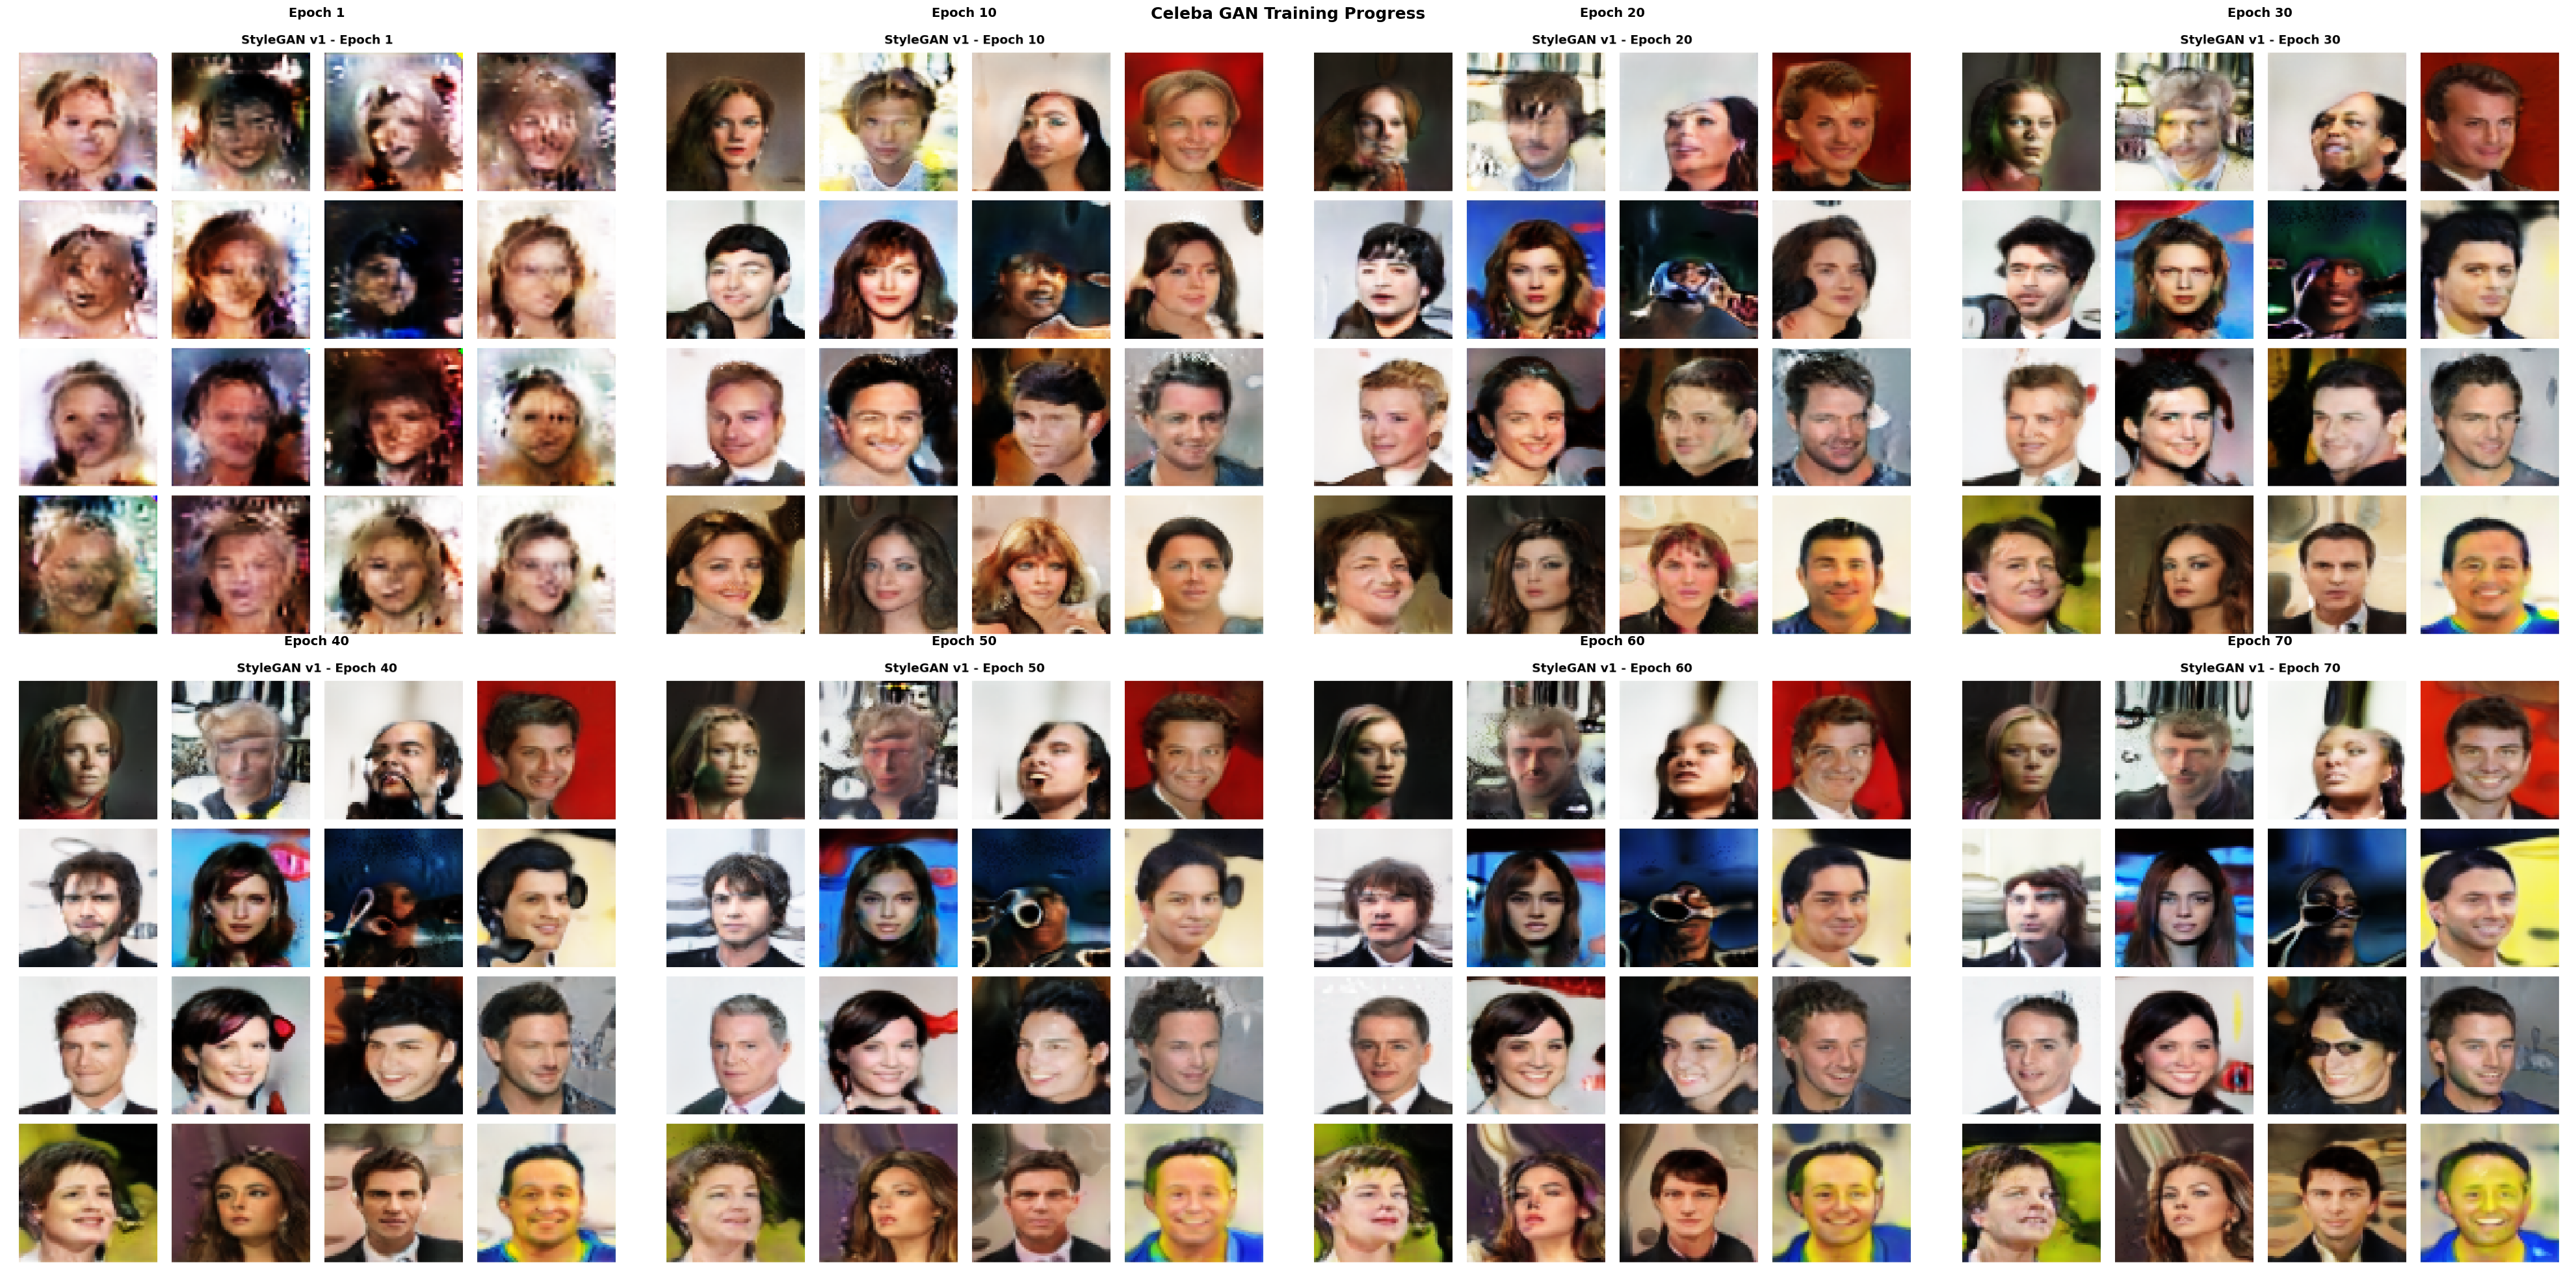

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

epochs=[1, 10, 20, 30, 40, 50, 60, 70]

n_epochs = len(epochs)
fig, axes = plt.subplots(2, 4, figsize=(40, 20))
axes = axes.flatten()

for idx, epoch in enumerate(epochs):
    try:
        img_path = f'stylegan/stylegan_v1_epoch_{epoch}.png'
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f'Epoch {epoch}', fontsize=14, fontweight='bold')
        axes[idx].axis('off')
    except FileNotFoundError:
        axes[idx].text(0.5, 0.5, f'Epoch {epoch}\nNot Found', 
                      ha='center', va='center', fontsize=12)
        axes[idx].axis('off')

plt.suptitle('Celeba GAN Training Progress', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('training_progress_celeba.png', dpi=150, bbox_inches='tight')
plt.show()

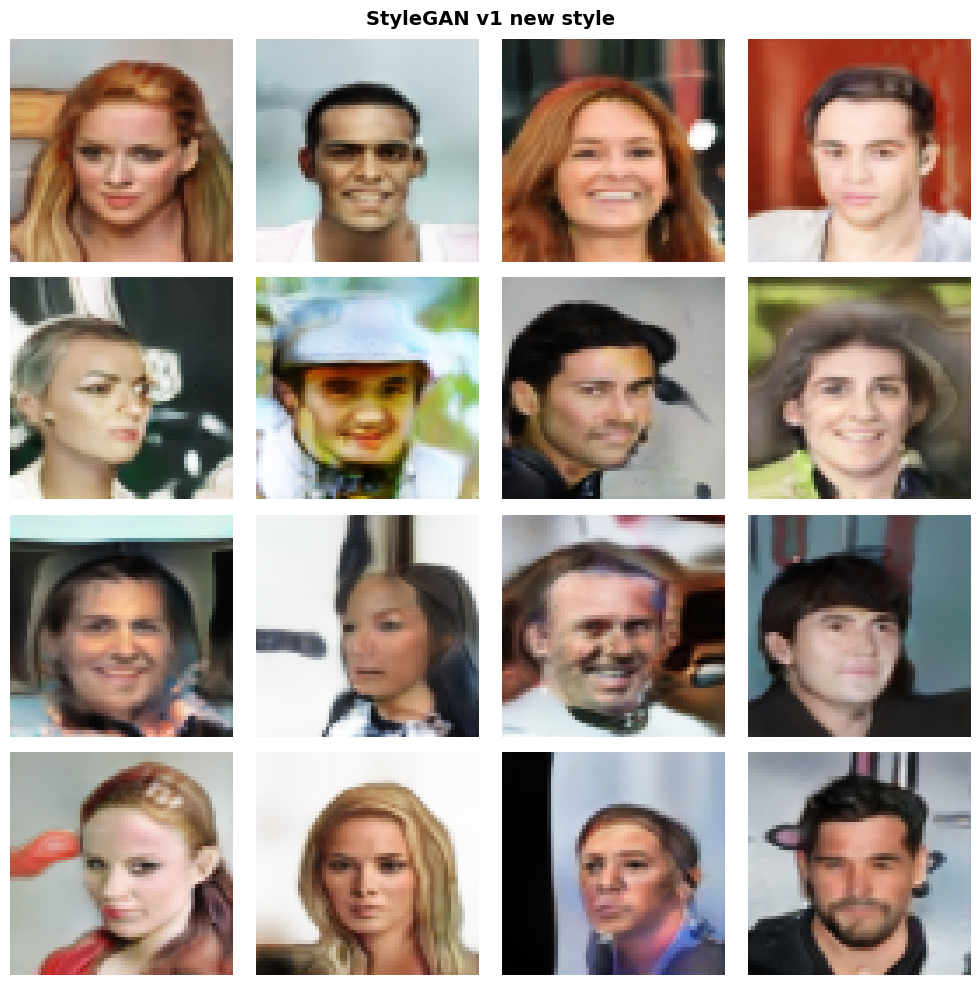

In [10]:
new_z = torch.randn(16, 512, device=device)
samples = gen(new_z)
                
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for idx, ax in enumerate(axes.flatten()):
    img = samples[idx].cpu().permute(1, 2, 0).detach().numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle(f'StyleGAN v1 new style', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()